# Willett Reconstruction Baseline

Minimal Colab notebook for training the native-cache Willett-style GRU baseline and plotting convergence diagnostics.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = Path('/content/utah-ssl')
REPO_URL = 'https://github.com/ethan-read/utah-ssl.git'

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git pull --ff-only || true

%cd {REPO_DIR}
!pip install -q torch pandas matplotlib

RAW_CACHE_ROOT = Path('/content/drive/MyDrive/utah_ssl/data/cache_v1')
SMOOTHED_CACHE_ROOT = Path('/content/drive/MyDrive/utah_ssl/data/cache_v1_smoothed_sigma2p0')
TRIM_SCRIPT = REPO_DIR / 'analysis' / 'active' / 'ssl_experiments' / 'trim_area6v_cache.py'
OUTPUT_ROOT = Path('/content/drive/MyDrive/utah_ssl/outputs/willett_reconstruction')
EXPERIMENTS_DIR = REPO_DIR / 'analysis' / 'active' / 'ssl_experiments'
PYTHONPATH = str(EXPERIMENTS_DIR)
os.environ['PYTHONPATH'] = PYTHONPATH
if PYTHONPATH not in sys.path:
    sys.path.insert(0, PYTHONPATH)

for cache_root in (RAW_CACHE_ROOT, SMOOTHED_CACHE_ROOT):
    dataset_root = cache_root / 'brain2text24'
    if dataset_root.exists():
        subprocess.run(
            ['python', str(TRIM_SCRIPT), '--cache-root', str(cache_root)],
            check=True,
            cwd=str(REPO_DIR),
        )

print('RAW_CACHE_ROOT:', RAW_CACHE_ROOT)
print('SMOOTHED_CACHE_ROOT:', SMOOTHED_CACHE_ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)


Mounted at /content/drive
Cloning into '/content/utah-ssl'...
remote: Enumerating objects: 855, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 855 (delta 70), reused 122 (delta 50), pack-reused 691 (from 1)
Receiving objects: 100% (855/855), 3.72 MiB | 7.42 MiB/s, done.
Resolving deltas: 100% (401/401), done.
/content/utah-ssl


In [2]:
from pathlib import Path

RUN_NAME = 'willett_tx_only_area6v_colab'
DATASET = 'brain2text24'
FEATURE_MODE = 'tx_only'
CACHE_ROOT = RAW_CACHE_ROOT
MAX_STEPS = 12000
BATCH_SIZE = 64
SESSION_ADAPTER = True
NORMALIZATION_MODE = 'global'
RESUME_LATEST = False

RUN_DIR = OUTPUT_ROOT / RUN_NAME
RUN_DIR

PosixPath('/content/drive/MyDrive/utah_ssl/outputs/willett_reconstruction/willett_tx_only_area6v_colab')

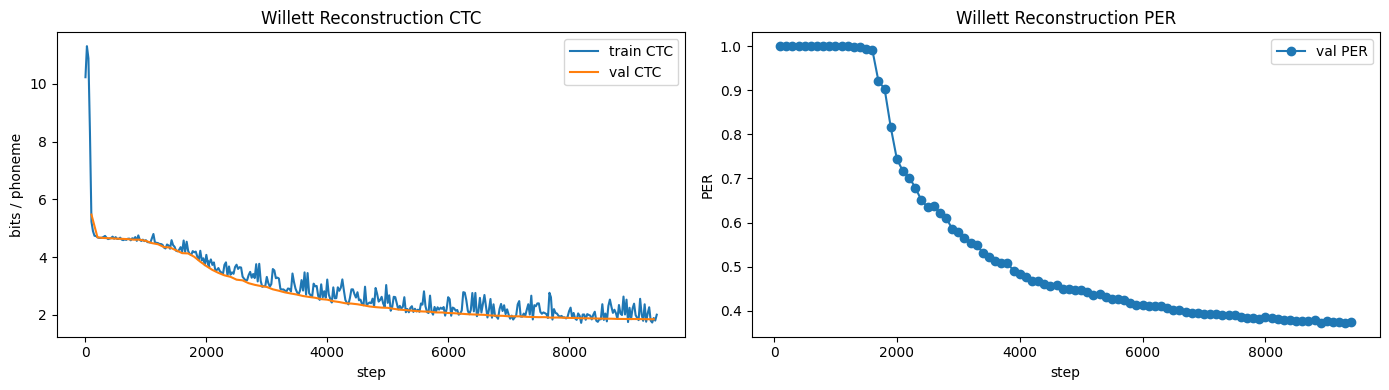

No summary.json yet (run likely interrupted).
Latest val log from progress.jsonl: {'step': 9400, 'val_ctc_bpphone': 1.8477595003006333, 'val_phoneme_error_rate': 0.3748503488420097, 'blank_frame_rate': None, 'predicted_to_reference_token_ratio': None}


In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = OUTPUT_ROOT / RUN_NAME
progress_path = RUN_DIR / "progress.jsonl"
summary_path = RUN_DIR / "summary.json"

assert progress_path.exists(), f"Missing: {progress_path}"

progress = [json.loads(line) for line in progress_path.read_text().splitlines() if line.strip()]
df = pd.DataFrame(progress)

train_df = df[df.get("event").eq("willett_train_report")] if "event" in df.columns else pd.DataFrame()
val_df = df[df.get("event").eq("willett_val_report")] if "event" in df.columns else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if not train_df.empty and "step" in train_df and "train_ctc_bpphone" in train_df:
    axes[0].plot(train_df["step"], train_df["train_ctc_bpphone"], label="train CTC")
if not val_df.empty and "step" in val_df and "val_ctc_bpphone" in val_df:
    axes[0].plot(val_df["step"], val_df["val_ctc_bpphone"], label="val CTC")
axes[0].set_title("Willett Reconstruction CTC")
axes[0].set_xlabel("step")
axes[0].set_ylabel("bits / phoneme")
axes[0].legend()

if not val_df.empty and "step" in val_df and "val_phoneme_error_rate" in val_df:
    axes[1].plot(val_df["step"], val_df["val_phoneme_error_rate"], marker="o", label="val PER")
axes[1].set_title("Willett Reconstruction PER")
axes[1].set_xlabel("step")
axes[1].set_ylabel("PER")
axes[1].legend()

plt.tight_layout()
plt.show()

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print("best step:", summary.get("best_step"))
    print("final metrics:", summary.get("metrics", {}))
    print("best metrics:", summary.get("best_metrics", {}))
else:
    print("No summary.json yet (run likely interrupted).")
    if not val_df.empty:
        last = val_df.sort_values("step").iloc[-1].to_dict()
        print("Latest val log from progress.jsonl:", {k: last.get(k) for k in ["step","val_ctc_bpphone","val_phoneme_error_rate","blank_frame_rate","predicted_to_reference_token_ratio"]})

## Recompute Split Stats

Run this cell when `FEATURE_MODE` changes or after trimming/rebuilding the cache. It derives the canonical split-stats output path from the current config and refreshes the `competition_train` global normalization stats used by the Willett baseline.

In [ ]:
import json
import subprocess

from recompute_split_feature_stats import resolve_precomputed_split_stats_path

RECOMPUTE_SPLIT_STATS = True
SPLIT_STATS_SCRIPT = REPO_DIR / 'analysis' / 'active' / 'ssl_experiments' / 'recompute_split_feature_stats.py'

stats_output_path = resolve_precomputed_split_stats_path(
    cache_root=CACHE_ROOT,
    dataset=DATASET,
    train_split_name='competition_train',
    feature_mode=FEATURE_MODE,
    preferred_path=None,
)

trim_cmd = ['python', str(TRIM_SCRIPT), '--cache-root', str(CACHE_ROOT)]
print('Running:', ' '.join(trim_cmd))
trim_result = subprocess.run(trim_cmd, cwd=str(REPO_DIR), text=True, capture_output=True)
print('trim returncode:', trim_result.returncode)
if trim_result.stdout:
    print('\nTRIM STDOUT\n')
    print(trim_result.stdout)
if trim_result.stderr:
    print('\nTRIM STDERR\n')
    print(trim_result.stderr)
if trim_result.returncode != 0:
    raise RuntimeError('Area-6v cache trim failed before stats recompute.')

if RECOMPUTE_SPLIT_STATS:
    cmd = [
        'python', str(SPLIT_STATS_SCRIPT),
        '--cache-root', str(CACHE_ROOT),
        '--dataset', DATASET,
        '--feature-mode', FEATURE_MODE,
        '--output-path', str(stats_output_path),
        '--overwrite',
    ]
    print('Running:', ' '.join(cmd))
    result = subprocess.run(cmd, cwd=str(REPO_DIR), text=True, capture_output=True)
    print('stats returncode:', result.returncode)
    if result.stdout:
        print('\nSTATS STDOUT\n')
        print(result.stdout)
    if result.stderr:
        print('\nSTATS STDERR\n')
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError('Split stats recompute failed.')

metadata_path = stats_output_path.with_suffix('.json')
PRECOMPUTED_STATS_PATH = stats_output_path
print('Canonical split stats path:', stats_output_path)
if metadata_path.exists():
    metadata = json.loads(metadata_path.read_text())
    print(json.dumps(metadata, indent=2))
else:
    print('Missing metadata sidecar:', metadata_path)


In [ ]:
import os
import shlex

PACKAGE_ROOT = REPO_DIR / 'analysis' / 'active' / 'ssl_experiments'

cmd = [
    'python', '-m', 'willett_reconstruction.train',
    '--cache-root', str(CACHE_ROOT),
    '--output-root', str(OUTPUT_ROOT),
    '--run-name', RUN_NAME,
    '--dataset', DATASET,
    '--feature-mode', FEATURE_MODE,
    '--normalization-mode', NORMALIZATION_MODE,
    '--max-steps', str(MAX_STEPS),
    '--batch-size', str(BATCH_SIZE),
    '--val-every-steps', '100',
    '--checkpoint-every-steps', '500',
    '--progress-every-steps', '25',
]
if RESUME_LATEST:
    cmd.append('--resume-latest')
if not SESSION_ADAPTER:
    cmd.append('--disable-session-adapter')
full_cmd = ' '.join(shlex.quote(part) for part in cmd)
pythonpath = f"{PACKAGE_ROOT}:{os.environ.get('PYTHONPATH', '')}"

print(full_cmd)
!cd {PACKAGE_ROOT} && PYTHONPATH={pythonpath} {full_cmd}

python /content/utah-ssl/analysis/active/ssl_experiments/willett_reconstruction/train.py --cache-root /content/drive/MyDrive/utah_ssl/data/cache_v1 --output-root /content/drive/MyDrive/utah_ssl/outputs/willett_reconstruction --run-name willett_tx_only_area6v_colab --dataset brain2text24 --feature-mode tx_only --normalization-mode global --max-steps 12000 --batch-size 64 --val-every-steps 100 --checkpoint-every-steps 500 --progress-every-steps 25 --precomputed-split-stats-path /content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/raw/brain2text24/competition_train/tx_only/global_v1.pt
Traceback (most recent call last):
  File "/content/utah-ssl/analysis/active/ssl_experiments/willett_reconstruction/train.py", line 27, in <module>
    from .data import (
ImportError: attempted relative import with no known parent package


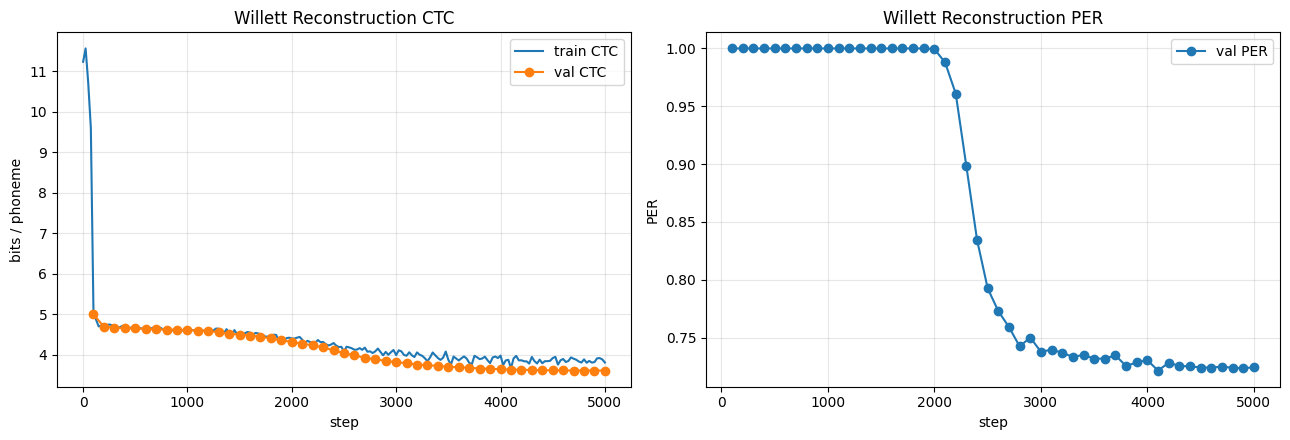

best step: 4100
final metrics: {
  "val_ctc_bpphone": 3.6103346972022106,
  "val_phoneme_error_rate": 0.7244354539074433,
  "edit_diagnostics": {
    "insertions": 1,
    "deletions": 16494,
    "substitutions": 1053
  },
  "collapse_diagnostics": {
    "total_reference_tokens": 24223,
    "total_predicted_tokens": 7730,
    "predicted_to_reference_token_ratio": 0.3191181934525038,
    "blank_frame_rate": 0.7613392451470381,
    "reference_top_ids": [
      [
        40,
        5498
      ],
      [
        3,
        1621
      ],
      [
        31,
        1585
      ],
      [
        23,
        1224
      ],
      [
        17,
        1130
      ],
      [
        29,
        877
      ],
      [
        28,
        794
      ],
      [
        9,
        757
      ],
      [
        21,
        729
      ],
      [
        18,
        670
      ]
    ],
    "prediction_top_ids": [
      [
        40,
        5230
      ],
      [
        31,
        944
      ],
      [
      

,step,val_ctc_bpphone,val_phoneme_error_rate
205,4100,3.635210,0.721546
210,4200,3.632840,0.728399
215,4300,3.624804,0.725550
220,4400,3.620924,0.725261
225,4500,3.617491,0.724229
230,4600,3.614028,0.724229
235,4700,3.612838,0.724972
240,4800,3.611464,0.723981
245,4900,3.610807,0.723610
250,5000,3.610335,0.724435


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt

summary_path = RUN_DIR / 'summary.json'
progress_path = RUN_DIR / 'progress.jsonl'
summary = json.loads(summary_path.read_text())
progress = [json.loads(line) for line in progress_path.read_text().splitlines() if line.strip()]
progress_df = pd.DataFrame(progress)
train_df = progress_df[progress_df['event'] == 'willett_train_report'].copy()
val_df = progress_df[progress_df['event'] == 'willett_val_report'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if not train_df.empty:
    axes[0].plot(train_df['step'], train_df['train_ctc_bpphone'], label='train CTC')
if not val_df.empty:
    axes[0].plot(val_df['step'], val_df['val_ctc_bpphone'], marker='o', label='val CTC')
    axes[1].plot(val_df['step'], val_df['val_phoneme_error_rate'], marker='o', label='val PER')
axes[0].set_title('Willett Reconstruction CTC')
axes[0].set_xlabel('step')
axes[0].set_ylabel('bits / phoneme')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].set_title('Willett Reconstruction PER')
axes[1].set_xlabel('step')
axes[1].set_ylabel('PER')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print('best step:', summary.get('best_step'))
print('final metrics:', json.dumps(summary.get('metrics', {}), indent=2))
print('best metrics:', json.dumps(summary.get('best_metrics', {}), indent=2))
if not val_df.empty:
    display(val_df[['step', 'val_ctc_bpphone', 'val_phoneme_error_rate']].tail(10))